# prepare_pillars() testing

In [3]:
%load_ext autoreload
%autoreload 2

from datetime import datetime, timedelta, date, timezone
from functools import partial
import numpy as np
import polars as pl

from okx.store import OrderbookStore
from okx.recipes.pillars import prepare_pillars
from okx.recipes.helpers import early_roll

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

In [4]:
store.clear_cache()

Cleared all caches


In [5]:
start_date = date(2025, 9, 1)
end_date = date(2025, 10, 1)
dates = [start_date + timedelta(days=i) for i in range((end_date - start_date).days)]
print(f"Date range constructed from {dates[0]} to {dates[-1]}")
shared_params = {
    'store': store,
    'inst_family': 'BTC-USD',
    'dates': dates,
    'verbose': True
}

Date range constructed from 2025-09-01 to 2025-09-30


Vefification function:

In [15]:
def verify_pillars(df):
    # Check if expiry is before timeMs
    print(f"Number of rows: {df.height}")
    cols = df.collect_schema().names()
    print(f"Columns:")
    for col in cols:
        print(f"{col:<12}: {df.select(col).schema[col]} with {df.select(col).unique().height} unique values and {df.select(col).null_count().item()} nulls")
    print("=== Pillar index checks ===")

    pillars = df.select('pillar_idx').unique().sort(by='pillar_idx').to_series().to_list()
    for pillar in pillars:
        pillar_df = df.filter(pl.col('pillar_idx') == pillar)
        pillar_symbols = pillar_df.select('symbol').unique().to_series().sort().to_list()
        print(f" - Pillar {pillar} has {pillar_df.height} rows with the following symbols: {pillar_symbols}")
    print("=== Expiry/Tenor checks ===")

    expiry_check = df.filter(pl.col('pillar_idx') != 0).filter(pl.col('expiry') < pl.col('timeMs'))
    if expiry_check.height > 0:
        print(f"WARNING: {expiry_check.height} rows where expiry < timeMs")
        print(f" - {expiry_check.head(10)}")
    min_T = df.filter(pl.col('pillar_idx') != 0).select('T').min().item()
    print(f"Minimum T excluding swap rows: {min_T} = {min_T * 365 * 24 * 3600} seconds")
    expiry_minus_timeMs = (
        df
        .filter(pl.col('pillar_idx') != 0)
        .with_columns([(pl.col('expiry') - pl.col('timeMs')).alias('expiry_minus_timeMs')])
    )
    min_expiry_minus_timeMs = expiry_minus_timeMs.select('expiry_minus_timeMs').min().item()
    print(f"Minimum expiry - timeMs (ms) excluding swap rows: {min_expiry_minus_timeMs} = {min_expiry_minus_timeMs / 1000} seconds")

    # Null and zero checks - prints conditionally

    null_bid = df.filter(pl.col('ln_bid_1_px').is_null())
    null_ask = df.filter(pl.col('ln_ask_1_px').is_null())
    null_both = df.filter(pl.col('ln_bid_1_px').is_null() & pl.col('ln_ask_1_px').is_null())
    if null_bid.height > 0 or null_ask.height > 0 or null_both.height > 0:
        print("=== Null checks ===")
    if null_bid.height > 0:
        print(f"{null_bid.height} rows with null bid")
    if null_ask.height > 0:
        print(f"{null_ask.height} rows with null ask")
    if null_both.height > 0:
        print(f"{null_both.height} rows with null bid and ask")

    zero_bid = df.filter(pl.col('ln_bid_1_px') == 0)
    zero_ask = df.filter(pl.col('ln_ask_1_px') == 0)
    zero_both = df.filter((pl.col('ln_bid_1_px') == 0) & (pl.col('ln_ask_1_px') == 0))
    if zero_bid.height > 0 or zero_ask.height > 0 or zero_both.height > 0:
        print("=== Zero checks ===")
    if zero_bid.height > 0:
        print(f"{zero_bid.height} rows with zero bid")
    if zero_ask.height > 0:
        print(f"{zero_ask.height} rows with zero ask")
    if zero_both.height > 0:
        print(f"{zero_both.height} rows with zero bid and ask")
    print("=== Symbol checks ===")

    symbols = df.select('symbol').unique().to_series().sort().to_list()
    print(f"{len(symbols)} unique symbols:")
    for symbol in symbols:
        print(f"{symbol:<20}: {df.filter(pl.col('symbol') == symbol).height} rows")
    print("=== Sorting checks ===")
    
    # Verify df is sorted by [timeMs, T] using Polars
    is_sorted = df.equals(df.sort(['timeMs', 'T']))
    print(f"DataFrame is sorted by [timeMs, T]: {is_sorted}")
    print("=== Completion checks ===")
    # Aggregation: Check for "missing" timeMs (must have both swap (T=0, pillar_idx==0) and at least one other row for that timeMs)

    # Group by timeMs, check for presence of swap and future
    agg = (
        df
        .group_by("timeMs")
        .agg([
            pl.col("pillar_idx").min().alias("min_pillar_idx"),
            pl.col("pillar_idx").max().alias("max_pillar_idx"),
            (pl.col("pillar_idx") == 0).sum().alias("swap_count"),
            (pl.col("pillar_idx") != 0).sum().alias("future_count"),
            pl.len().alias("pillar_row_count"),
        ])
    )

    # timeMs that do NOT have both a swap and a future
    missing = agg.filter(
        (pl.col("swap_count") == 0) | (pl.col("future_count") == 0)
    )

    if missing.height > 0:
        print(f"WARNING: {missing.height} timeMs are missing a swap or future for that instant.")
        print("Examples:")
        print(missing.head(10))
    else:
        print("All timeMs have both a swap and at least one future contract.")

    # Report the minimum and maximum pillar count per timeMs
    min_pillars = agg["pillar_row_count"].min()
    max_pillars = agg["pillar_row_count"].max()
    print(f"Minimum pillar count per timeMs: {min_pillars}")
    print(f"Maximum pillar count per timeMs: {max_pillars}")

## Test with binning

In [6]:
start = datetime.now()
pillars_lf = prepare_pillars(
    binning='10s',
    **shared_params
)
end = datetime.now()
print(f"Time taken: {end - start}")
pillars_df = pillars_lf.collect()
print(f"Time taken to collect: {datetime.now() - end}")

Constructing pillars for BTC-USD with swap and futures using 10s binning
 - Time taken to fetch swap and futures: 0:00:19.112167
 - Time taken to align snapshots: 0:00:00.004948
 - Time taken to concatenate and filter: 0:00:00.021672
 - Time taken to index and sort pillars: 0:00:00.000203
 - Total time taken to prepare pillars: 0:00:19.138990
Time taken: 0:00:19.141688
Time taken to collect: 0:00:00.143559


In [45]:
problematic_pillars_df = pillars_lf.filter(pl.col('rel_spread') < 0.0).collect()

first_timeMs = problematic_pillars_df['timeMs'].min()
last_timeMs = problematic_pillars_df['timeMs'].max()
print(f"In a full month of pillar data, there are {problematic_pillars_df.height} rows with a negative spread")
print(f"Earliest occurrence: {datetime.fromtimestamp(first_timeMs / 1000, tz=timezone.utc)}")
print(f"Latest occurrence: {datetime.fromtimestamp(last_timeMs / 1000, tz=timezone.utc)}")

In a full month of pillar data, there are 38 rows with a negative spread
Earliest occurrence: 2025-09-04 03:13:20+00:00
Latest occurrence: 2025-09-04 03:14:00+00:00


let's see if we can get to the bottom of this...

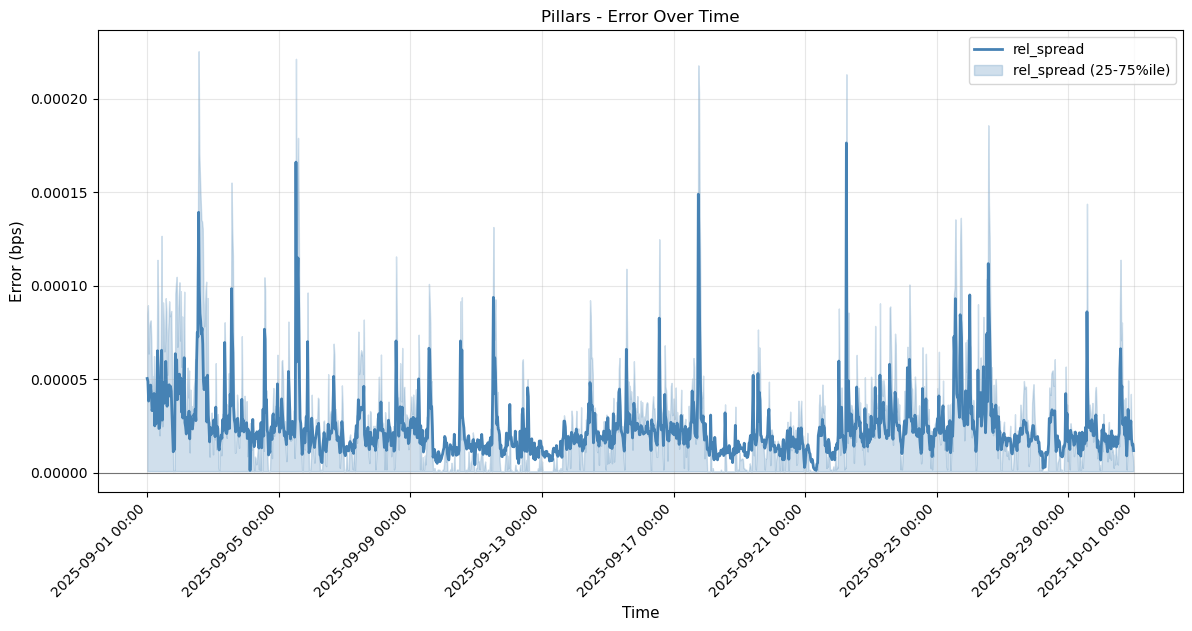

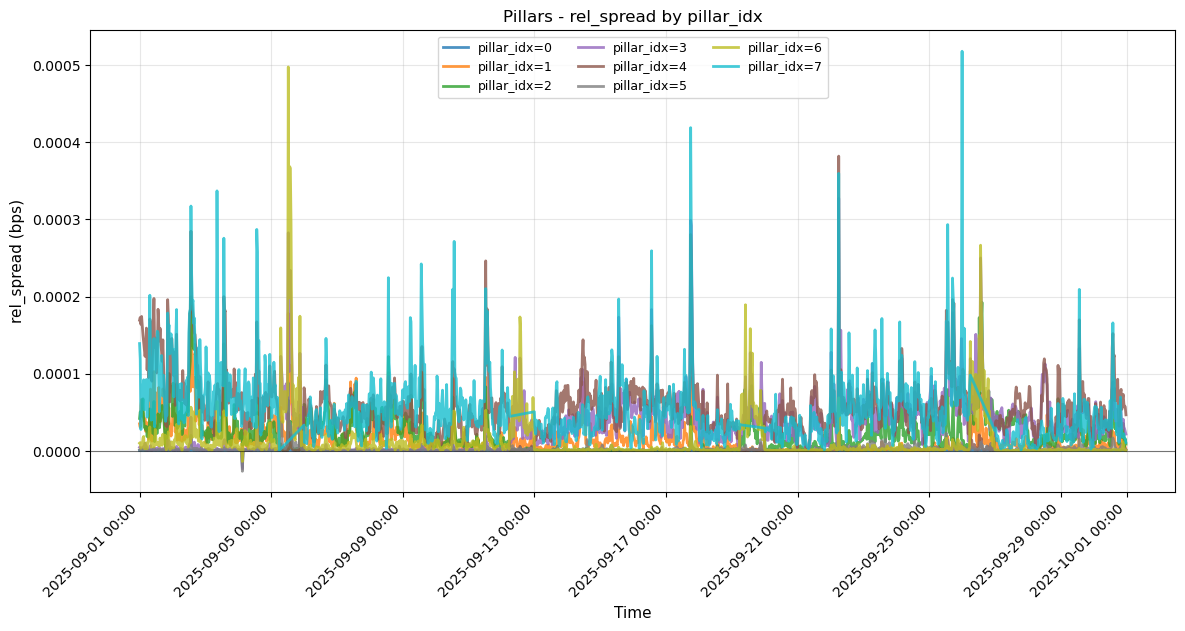

In [9]:
from evaluation.plotting import plot_error_over_time, plot_error_by_group
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
plot_error_over_time(pillars_lf, 'pillars', 'rel_spread', ax=ax, resample_freq='30m')
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))
plot_error_by_group(pillars_lf, 'pillars', 'rel_spread', 'pillar_idx', ax=ax, resample_freq='30m')
plt.show()


In [19]:
verify_pillars(pillars_df)

Number of rows: 2047672
Columns:
symbol      : String with 12 unique values and 0 nulls
timeMs      : Int64 with 259199 unique values and 0 nulls
rel_spread  : Float64 with 775652 unique values and 0 nulls
expiry      : Int64 with 259206 unique values and 0 nulls
T           : Float64 with 1393197 unique values and 0 nulls
ln_bid_1_px : Float64 with 157225 unique values and 0 nulls
ln_ask_1_px : Float64 with 157243 unique values and 0 nulls
pillar_idx  : Int64 with 8 unique values and 0 nulls
=== Pillar index checks ===
 - Pillar 0 has 259199 rows with the following symbols: ['BTC-USD-SWAP.OK']
 - Pillar 1 has 259199 rows with the following symbols: ['BTC-USD-250905.OK', 'BTC-USD-250912.OK', 'BTC-USD-250919.OK', 'BTC-USD-250926.OK', 'BTC-USD-251003.OK']
 - Pillar 2 has 259199 rows with the following symbols: ['BTC-USD-250912.OK', 'BTC-USD-250919.OK', 'BTC-USD-250926.OK', 'BTC-USD-251003.OK', 'BTC-USD-251010.OK', 'BTC-USD-251031.OK']
 - Pillar 3 has 259199 rows with the following symbol

## Test with unique_times
Best to use a shorter timeframe to avoid memory issues:

In [8]:
dates = dates[:2]
print(f"Date range constructed from {dates[0]} to {dates[-1]}")

Date range constructed from 2025-09-15 to 2025-09-16


Gather unique times:

In [9]:
options_df = store.get(
    inst_type='OPTION',
    inst_family='BTC-USD',
    dates=dates,
    depth=1,
    features=['trim', 'strip']
).collect()
unique_times = options_df['timeMs'].unique().sort().to_list()
print(f"{len(unique_times)} unique times found")

9503022 unique times found


In [12]:
start = datetime.now()
pillars_lf = prepare_pillars(
    unique_times=unique_times,
    **shared_params
)
end = datetime.now()
print(f"Time taken: {end - start}")
pillars_df = pillars_lf.collect()
print(f"Time taken to collect: {datetime.now() - end}")

Constructing pillars for BTC-USD with swap and futures using provided timestamps
Time taken to fetch swap and futures: 0:00:00.366796
Time taken to align snapshots: 0:00:00.138461
Time taken to concatenate and filter: 0:00:11.394912
Time taken to index and sort pillars: 0:00:00.000672
Total time taken to prepare pillars: 0:00:11.900841
Time taken: 0:00:11.906561
Time taken to collect: 0:00:24.562268


In [16]:
verify_pillars(pillars_df)

Number of rows: 76024167
Columns:
symbol      : String with 8 unique values and 0 nulls
timeMs      : Int64 with 9503022 unique values and 0 nulls
rel_spread  : Float64 with 1510122 unique values and 0 nulls
expiry      : Int64 with 5999369 unique values and 0 nulls
T           : Float64 with 16861315 unique values and 0 nulls
ln_bid_1_px : Float64 with 89212 unique values and 0 nulls
ln_ask_1_px : Float64 with 89382 unique values and 0 nulls
pillar_idx  : Int64 with 8 unique values and 0 nulls
=== Pillar index checks ===
 - Pillar 0 has 9503022 rows with the following symbols: ['BTC-USD-SWAP.OK']
 - Pillar 1 has 9503022 rows with the following symbols: ['BTC-USD-250919.OK', 'BTC-USD-260327.OK']
 - Pillar 2 has 9503021 rows with the following symbols: ['BTC-USD-250926.OK']
 - Pillar 3 has 9503021 rows with the following symbols: ['BTC-USD-251031.OK', 'BTC-USD-251226.OK']
 - Pillar 4 has 9503021 rows with the following symbols: ['BTC-USD-251128.OK', 'BTC-USD-260327.OK']
 - Pillar 5 has 

In [15]:
del pillars_df
del pillars_lf

## Replicate futures forward pipeline to track down null column appearance

Solved by fixing bin_ff to not populate rows before a symbols first appearance

In [14]:
def get_first_and_last_ts(lf, symbols):
    """Returns a dict: symbol -> dict with first_ms, last_ms, first_dt, last_dt."""
    results = {}
    for symbol in symbols:
        res = (
            lf.filter(pl.col('symbol') == symbol)
            .select([
                pl.col('timeMs').min().alias('first_ms'),
                pl.col('timeMs').max().alias('last_ms'),
            ])
            .collect()
        )
        # If symbol is not present, skip
        if res.height == 0 or res['first_ms'][0] is None:
            results[symbol] = {
                'first_ms': None,
                'last_ms': None,
                'first_dt': None,
                'last_dt': None,
            }
        else:
            first_ms = res['first_ms'][0]
            last_ms = res['last_ms'][0]
            first_dt = datetime.fromtimestamp(first_ms / 1000, tz=timezone.utc)
            last_dt  = datetime.fromtimestamp(last_ms / 1000, tz=timezone.utc)
            results[symbol] = {
                'first_ms': first_ms,
                'last_ms': last_ms,
                'first_dt': first_dt,
                'last_dt': last_dt,
            }
    return results

def null_search(lf, symbols):
    """Returns a dict: symbol -> dict with null_count and the null DataFrame (head 10)."""
    # Determine whether log-space columns are present
    schema_cols = lf.collect_schema().names()
    if 'ln_bid_1_px' in schema_cols and 'ln_ask_1_px' in schema_cols:
        bid_col = 'ln_bid_1_px'
        ask_col = 'ln_ask_1_px'
    else:
        bid_col = 'bid_1_px'
        ask_col = 'ask_1_px'
    # Take the union of baseline and available columns in schema
    collect_cols = ['timeMs', 'symbol', bid_col, ask_col, 'time_bin']
    cols = [col for col in collect_cols if col in schema_cols]
        
    results = {}
    for symbol in symbols:
        null_df = (
            lf.filter(pl.col('symbol') == symbol)
            .filter(pl.col(bid_col).is_null() & pl.col(ask_col).is_null())
            .select(cols).collect()
        )
        null_count = null_df.height
        # Only keep first 10 to avoid giant output
        null_head = null_df.head(10) if null_count > 0 else null_df
        results[symbol] = {
            'null_count': null_count,
            'null_rows': null_head,
        }
    return results

def count_dupes(lf):
    """Counts the number of duplicate rows in a LazyFrame."""
    df = lf.collect()
    total_rows = df.height
    unique_rows = df.unique().height
    return total_rows - unique_rows
    

def test_stage(stage: str, features: list, shared_params: dict):
    print(f"\n=== Step {stage}: ===")
    lf = store.get(features=features, cache_name=f'test_cache_{stage}', **shared_params)
    symbols = lf.select('symbol').unique().collect()['symbol'].to_list()
    print("Data fetched")
    dupes = count_dupes(lf)
    print(f"Duplicate rows: {dupes}")

    minmax = get_first_and_last_ts(lf, symbols)
    print("Timestamps tested")
    nulls = null_search(lf, symbols)
    print("Nulls tested")
    for symbol, data in nulls.items():
        if data['null_count'] > 0:
            print(f"{symbol}: {data['null_count']} null rows")
            print(data['null_rows'])
    return lf, symbols, minmax, nulls

In [15]:
def add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls):
    for symbol in symbols:
        if symbol not in side_by_side:
            side_by_side[symbol] = {}
        side_by_side[symbol][stage] = {
            'first_dt': minmax[symbol]['first_dt'],
            'last_dt': minmax[symbol]['last_dt'],
            'null_count': nulls[symbol]['null_count'],
        }

shared_params = {
    'inst_family': 'BTC-USD',
    'inst_type': 'FUTURES',
    'dates': dates,
    'depth': 1,
    'verbose': True,
    'batch_days': None
}
side_by_side = {}

print("\n=== Step 1: Fetch raw futures data ===")
stage = 'trim_strip'
_, symbols, minmax, nulls = test_stage(stage, ['trim', 'strip'], shared_params)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)

print("\n=== Step 2: After bin_ff (10s with forward fill) ===")
stage = 'bin_ff'
shared_params['binning'] = '10s'
_, symbols, minmax, nulls = test_stage(stage, ['trim', 'strip', 'bin_ff'], shared_params)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)

print("\n=== Step 3: After finalize_binning ===")
stage = 'finalize_binning'
_, symbols, minmax, nulls = test_stage(stage, ['trim', 'strip', 'bin_ff', finalize_binning], shared_params)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)

print("\n=== Step 4: After rel_spread ===")
stage = 'rel_spread'
_, symbols, minmax, nulls = test_stage(stage, ['trim', 'strip', 'bin_ff', finalize_binning, 'rel_spread'], shared_params)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)

print("\n=== Step 5: After tenor ===")
stage = 'tenor'
_, symbols, minmax, nulls = test_stage(stage, ['trim', 'strip', 'bin_ff', finalize_binning, 'rel_spread', 'tenor'], shared_params)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)

print("\n=== Step 6: After log ===")
stage = 'log'
_, symbols, minmax, nulls = test_stage(
    stage,
    ['trim', 'strip', 'bin_ff', finalize_binning, 'rel_spread', 'tenor', 'log'],
    shared_params,
)
add_to_side_by_side(side_by_side, stage, symbols, minmax, nulls)




=== Step 1: Fetch raw futures data ===

=== Step trim_strip: ===
[store] Applying transforms for BTC-USD/FUTURES (depth=1, binning=None, features=['trim', 'strip'])
  - applied 'trim'
  - applied 'strip'
Data fetched
Duplicate rows: 674
Timestamps tested
Nulls tested

=== Step 2: After bin_ff (10s with forward fill) ===

=== Step bin_ff: ===
[store] Applying transforms for BTC-USD/FUTURES (depth=1, binning=10s, features=['trim', 'strip', 'bin_ff'])
  - applied 'trim'
  - applied 'strip'
  - applied 'bin_ff'
Data fetched
Duplicate rows: 0
Timestamps tested
Nulls tested

=== Step 3: After finalize_binning ===

=== Step finalize_binning: ===
[store] Applying transforms for BTC-USD/FUTURES (depth=1, binning=10s, features=['trim', 'strip', 'bin_ff', <function finalize_binning at 0x13a0b60c0>])
  - applied 'trim'
  - applied 'strip'
  - applied 'bin_ff'
  - applied 'finalize_binning'
Data fetched
Duplicate rows: 0
Timestamps tested
Nulls tested

=== Step 4: After rel_spread ===

=== Step re

In [16]:
print("\n=== Side-by-side summary ===")
# Dynamically print all available stages for each symbol in side_by_side

def format_dt(dt):
    # dt: int milliseconds or a datetime or None
    if dt is None:
        return "         "
    if isinstance(dt, int):
        # Assume ms since epoch
        dt = datetime.utcfromtimestamp(dt / 1000)
    elif isinstance(dt, float):
        dt = datetime.utcfromtimestamp(dt / 1000)
    # Show as "MM-DD HH:MM:SS"
    return dt.strftime("%m-%d %H:%M:%S")

for symbol, info in side_by_side.items():
    print(f"{symbol}:")
    # Print table header
    print(f"{'STAGE':<20} {'FIRST TIME':<16} {'LAST TIME':<16} {'NULL COUNT':<10}")
    print("-" * 54)
    for stage, details in info.items():
        first_str = format_dt(details.get('first_dt'))
        last_str = format_dt(details.get('last_dt'))
        null_count = details.get('null_count', "")
        print(f"{stage.upper():<20} {first_str:<16} {last_str:<16} {null_count:<10}")
    print()


=== Side-by-side summary ===
BTC-USD-250926.OK:
STAGE                FIRST TIME       LAST TIME        NULL COUNT
------------------------------------------------------
TRIM_STRIP           09-15 00:00:00   09-16 23:59:59   0         
BIN_FF               09-15 00:00:09   09-16 23:59:59   0         
FINALIZE_BINNING     09-15 00:00:10   09-16 23:59:50   0         
REL_SPREAD           09-15 00:00:10   09-16 23:59:50   0         
TENOR                09-15 00:00:10   09-16 23:59:50   0         
LOG                  09-15 00:00:10   09-16 23:59:50   0         

BTC-USD-260327.OK:
STAGE                FIRST TIME       LAST TIME        NULL COUNT
------------------------------------------------------
TRIM_STRIP           09-15 00:00:00   09-16 23:59:59   0         
BIN_FF               09-15 00:00:09   09-16 23:59:59   0         
FINALIZE_BINNING     09-15 00:00:10   09-16 23:59:50   0         
REL_SPREAD           09-15 00:00:10   09-16 23:59:50   0         
TENOR                09-15 00